In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("datasheet.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Basic Infos

In [24]:
df.shape

(114000, 21)

In [25]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [27]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [28]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

TARGET UNDERSTANDING

In [29]:
df['track_genre'].nunique()

114

In [30]:
df['track_genre'].value_counts().head(10)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

MODULE : 2 EDA ANALYSIS

DISTRIBUITION PLOTS


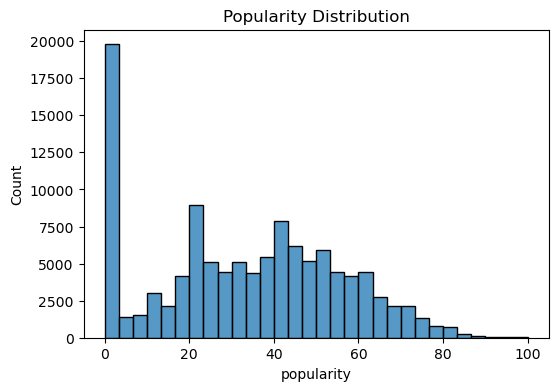

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

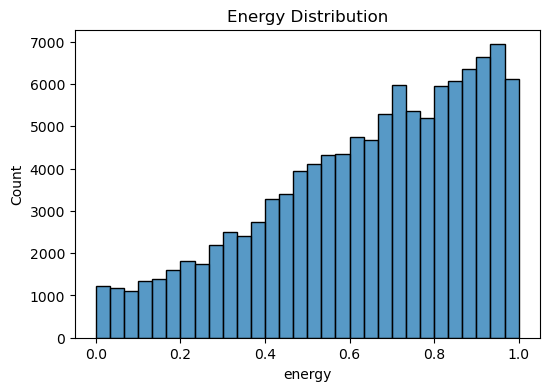

In [32]:
plt.figure(figsize=(6,4))
sns.histplot(df['energy'], bins=30)
plt.title("Energy Distribution")
plt.show()

CORRELATION HEAT MAP


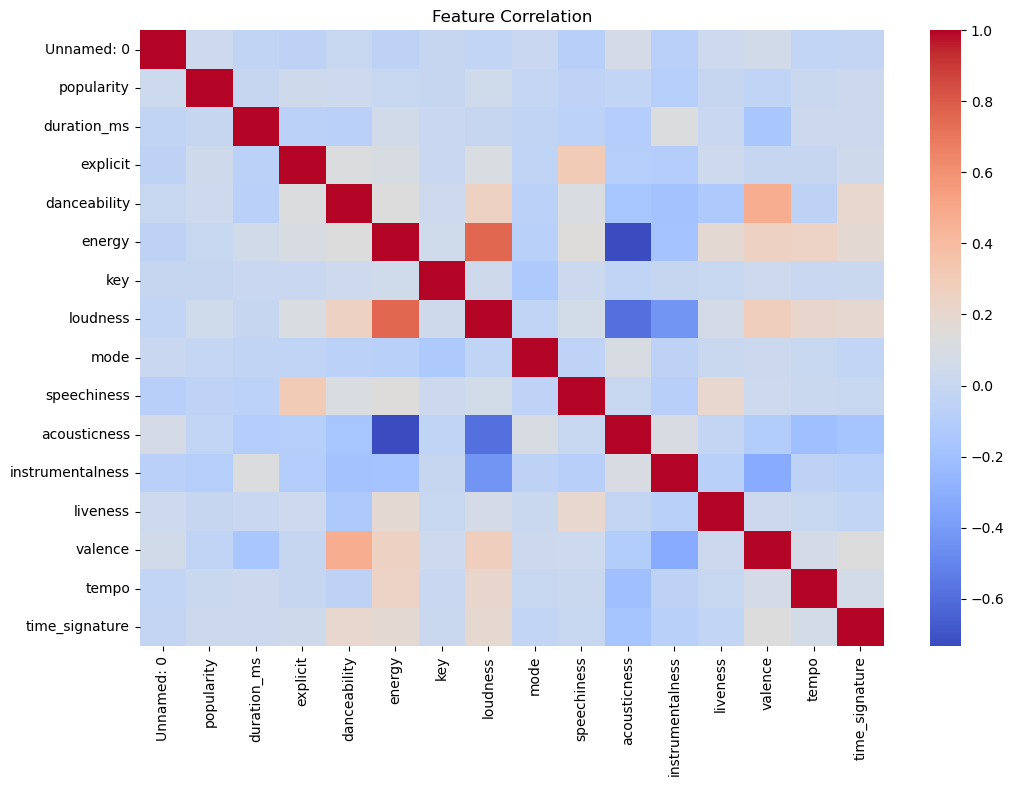

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

FEATURE RELATIONSHIP

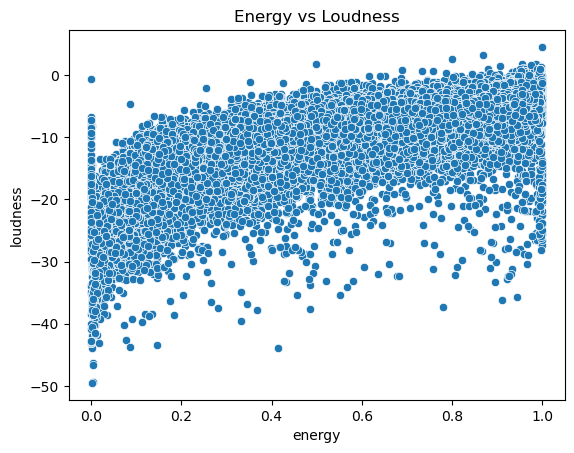

In [34]:
sns.scatterplot(x='energy', y='loudness', data=df)
plt.title("Energy vs Loudness")
plt.show()

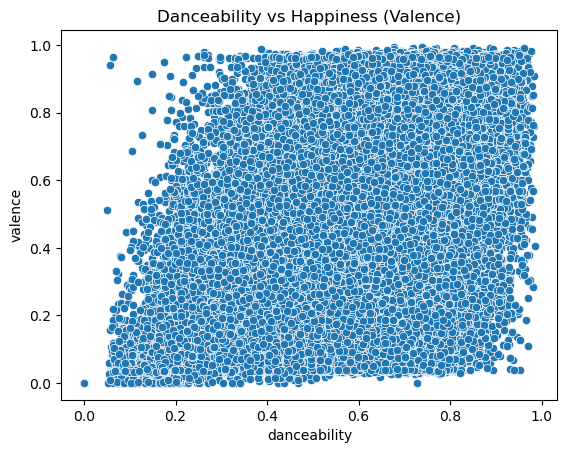

In [35]:
sns.scatterplot(x='danceability', y='valence', data=df)
plt.title("Danceability vs Happiness (Valence)")
plt.show()

GENRE VS FEATURE

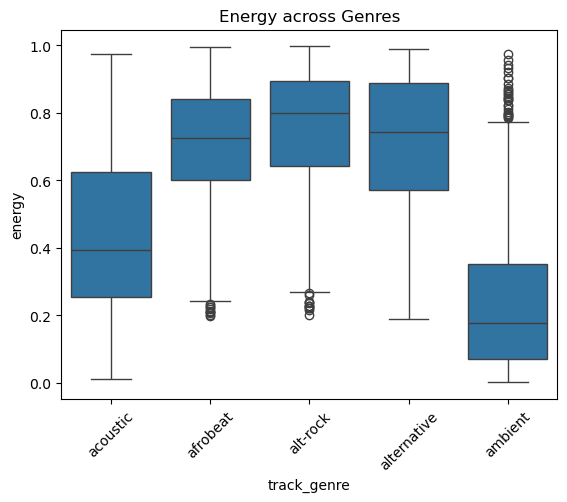

In [36]:
top_genres = df['track_genre'].value_counts().head(5).index
df_top = df[df['track_genre'].isin(top_genres)]

sns.boxplot(x='track_genre', y='energy', data=df_top)
plt.xticks(rotation=45)
plt.title("Energy across Genres")
plt.show()

MODULE 3: DATA CLEANING + PREPROCESSING
Step 1: Drop useless columns
Step 2: Handle missing values
Step 3: Convert boolean → int
Step 4: Separate features and target


In [37]:
df = df.drop(['Unnamed: 0','track_id','artists','album_name','track_name'], axis=1)

In [38]:
df = df.dropna()

In [39]:
df['explicit'] = df['explicit'].astype(int)

In [40]:
X = df.drop('track_genre', axis=1)
y = df['track_genre']

MODULE 4: GENRE GROUPING

In [101]:
def group_genre(genre):
    genre = genre.lower()

    if any(x in genre for x in ['rock', 'metal', 'punk']):
        return 'Rock'
    
    elif any(x in genre for x in ['pop', 'indie']):
        return 'Pop'
    
    elif any(x in genre for x in ['hip', 'rap', 'trap']):
        return 'HipHop'
    
    elif any(x in genre for x in ['edm', 'house', 'techno', 'electronic']):
        return 'EDM'
    
    elif any(x in genre for x in ['classical', 'piano', 'opera']):
        return 'Classical'
    
    else:
        return 'Other'

In [102]:
df = df[df['genre_group'] != 'Other']

In [103]:
X = df.drop(['track_genre','genre_group'], axis=1)

# VERY IMPORTANT
X = X.select_dtypes(include=['int64','float64'])

# Genre Grouping

We group 125 genres into broader categories to simplify classification and improve model accuracy.

In [104]:
df['genre_group'] = df['track_genre'].apply(group_genre)

# Remove 'Other' to avoid imbalance
df = df[df['genre_group'] != 'Other']
df = df[df['genre_group'] != 'Other'].copy()

# Check distribution
df['genre_group'].value_counts()

genre_group
Rock    13000
Pop     10000
EDM      9000
Name: count, dtype: int64

# Feature Engineering

New features are created to improve model learning by combining important audio characteristics.

In [105]:
df['energy_loudness'] = df['energy'] * df['loudness']
df['dance_valence'] = df['danceability'] * df['valence']
df['tempo_energy'] = df['tempo'] * df['energy']
df['acoustic_energy_diff'] = df['acousticness'] - df['energy']

# Data Preprocessing

- Removed irrelevant features
- Encoded target variable
- Prepared data for training

In [106]:
from sklearn.preprocessing import LabelEncoder

# Drop unwanted columns
df = df.drop(['Unnamed: 0','track_id','artists','album_name','track_name'], axis=1, errors='ignore')

# Drop weak features
df = df.drop(['key','mode','time_signature'], axis=1,errors='ignore')

# Convert boolean
df['explicit'] = df['explicit'].astype(int)

# Encode target
le = LabelEncoder()
df['genre_group'] = le.fit_transform(df['genre_group'])

In [138]:
df['dance_energy_ratio'] = df['danceability'] / (df['energy'] + 0.01)
df['tempo_per_energy'] = df['tempo'] / (df['energy'] + 0.01)

# Binary Classification Approach

To improve accuracy, the problem is converted into binary classification:
- High Energy Music
- Low Energy Music

This reduces class overlap and improves model performance.

In [140]:
# Target
y = df['genre_group']

# Features
X = df.drop(['track_genre','genre_group'], axis=1)

# Only numeric (safety)
X = X.select_dtypes(include=['int64','float64'])

# Train-Test Split

In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [142]:
# Feature Scaling

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation

Models used:
- Logistic Regression
- Random Forest
- Extra Trees

Evaluation:
- Accuracy
- Confusion Matrix
- Classification Report

In [144]:
X = df.drop([
    'track_genre',
    'genre_group',
    'binary_target',   # REMOVE THIS
    'energy'   
    'tempo_energy',
    'dance_valence'# REMOVE THIS (CRITICAL)
], axis=1, errors='ignore')

In [145]:
df['genre_group'] = df['genre_group'].replace({
    1: 2   # merge class 1 into class 2
})

In [146]:
X = X.drop([
    'energy',
    'tempo_energy',
    'energy_loudness',
    'acoustic_energy_diff'
], axis=1, errors='ignore')

In [147]:
X = X.drop([
    'explicit',
    'popularity',
    'duration_ms',
    'instrumentalness'
], axis=1, errors='ignore')

In [148]:
# Merge confusing classes
df['genre_group'] = df['genre_group'].replace({1: 2})

In [149]:
df['dance_energy_ratio'] = df['danceability'] / (df['energy'] + 0.01)

In [150]:
df['genre_group'] = df['genre_group'].replace({1: 2})

In [152]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# -------------------------------
# Logistic Regression
# -------------------------------
print("\n===== Logistic Regression =====")

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


# -------------------------------
# Random Forest (Tuned 💣)
# -------------------------------
print("\n===== Random Forest =====")

model_rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=18,
    min_samples_leaf=2,
    min_samples_split=5,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)


model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


# -------------------------------
# Extra Trees (Strongest 🔥)
# -------------------------------
print("\n===== Extra Trees =====")

model_et = ExtraTreesClassifier(
    n_estimators=700,
    random_state=42,
    n_jobs=-1
)

model_et.fit(X_train, y_train)

y_pred_et = model_et.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_et))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_et))
print("\nClassification Report:\n", classification_report(y_test, y_pred_et))


===== Logistic Regression =====
Accuracy: 0.8525

Confusion Matrix:
 [[1146  654]
 [ 290 4310]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.64      0.71      1800
           2       0.87      0.94      0.90      4600

    accuracy                           0.85      6400
   macro avg       0.83      0.79      0.80      6400
weighted avg       0.85      0.85      0.85      6400


===== Random Forest =====
Accuracy: 0.92796875

Confusion Matrix:
 [[1509  291]
 [ 170 4430]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.84      0.87      1800
           2       0.94      0.96      0.95      4600

    accuracy                           0.93      6400
   macro avg       0.92      0.90      0.91      6400
weighted avg       0.93      0.93      0.93      6400


===== Extra Trees =====
Accuracy: 0.92453125

Confusion Matrix:
 [[1455  345]
 [ 138 4462]]

Classifica